In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
import sympy  
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error ,r2_score
from sklearn.preprocessing import LabelEncoder 
new = pd.read_csv("Dataset .csv")
data = pd.DataFrame(new)
print("initial data shape:", data.shape)
print(data.head(2))

initial data shape: (4411, 21)
   Restaurant ID   Restaurant Name  Country Code         City  \
0        6317637  Le Petit Souffle           162  Makati City   
1        6304287  Izakaya Kikufuji           162  Makati City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   

                                    Locality Verbose   Longitude   Latitude  \
0  Century City Mall, Poblacion, Makati City, Mak...  121.027535  14.565443   
1  Little Tokyo, Legaspi Village, Makati City, Ma...  121.014101  14.553708   

                     Cuisines  ...          Currency Has Table booking  \
0  French, Japanese, Desserts  ...  Botswana Pula(P)               Yes   
1                    Japanese  ...  Botswana Pula(P)               Yes

C:\Users\visha\AppData\Local\Temp\ipykernel_3200\553984099.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method = 'ffill', inplace = True)



linear regression Results:
r2 score:0.4277
rmse:1.0549

Decision Tree Results:
r2 score:0.9739
rmse:0.2254

random forest Results:
r2 score:0.9872
rmse:0.1577


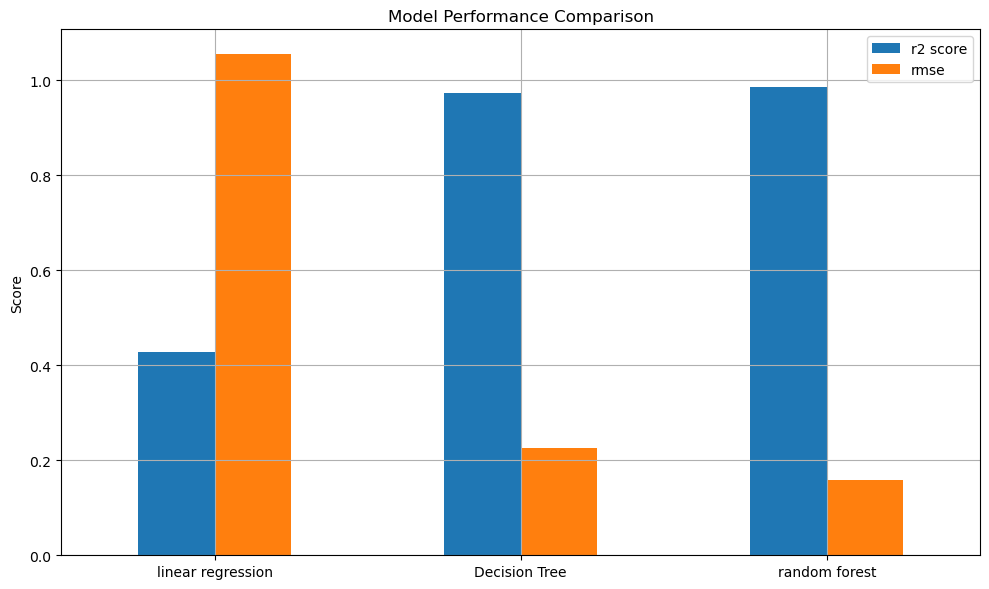

In [2]:
data = data.dropna(subset = ['Aggregate rating'])
data.fillna(method = 'ffill', inplace = True)
label_encoder = {}
for i in data.select_dtypes(include = ['object']).columns:
    le = LabelEncoder()
    data[i] = le.fit_transform(data[i])
    label_encoder[i]  = le

x = data.drop('Aggregate rating',axis = 1)
y = data['Aggregate rating']
#print(x)
#print(y)
x_train ,x_test , y_train ,y_test = train_test_split(x,y,test_size = 0.2 ,random_state = 42)

models = {
    'linear regression' : LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state= 42),
    'random forest' : RandomForestRegressor(random_state= 42 ,n_estimators= 100)
}
results = {}
for name,model in models.items():
    model.fit(x_train,y_train)
    predictions = model.predict(x_test)
    
    r2 = r2_score(y_test,predictions)
    rmse = np.sqrt(mean_squared_error(y_test,predictions))
    
    results[name] = {'r2 score': r2 ,'rmse':rmse}
    print(f"\n{name} Results:")
    print(f"r2 score:{r2:.4f}")
    print(f"rmse:{rmse:.4f}")
    

results_new = pd.DataFrame(results).T
results_new.plot(kind = 'bar',figsize = (10,6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation = 0)
plt.grid(True)
plt.tight_layout()
plt.show()
    

In [3]:
data = data.dropna(subset = ['Cuisines','Rating text','Votes'])
data['Cuisines'] = data['Cuisines'].mean()#.split(', ')
data_expload = data.explode('Cuisines')

# convert data types 
data_expload['Votes'] = pd.to_numeric(data_expload['Votes'], errors = 'coerce')
data_expload['Rating text'] = pd.to_numeric(data_expload['Rating text'], errors = 'coerce')
data_expload.dropna(subset = ['Rating text','Votes'],inplace = True)

avg_rate = data_expload.groupby('Cuisines')['Rating text'].mean().sort_values(ascending = False)
print("\n average rating per cuisine :\n" ,avg_rate)


 average rating per cuisine :
 Cuisines
653.629478    1.90907
Name: Rating text, dtype: float64


In [4]:
total_votes = data_expload.groupby('Cuisines')['Rating text'].sum().sort_values(ascending = False)
print(f"\n most popular cuisines :{total_votes}")


 most popular cuisines :Cuisines
653.629478    8419
Name: Rating text, dtype: int32


C:\Users\visha\AppData\Local\Temp\ipykernel_3200\2996304262.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = high_rate.head(5), y = high_rate.head(5).index,palette = 'viridis')


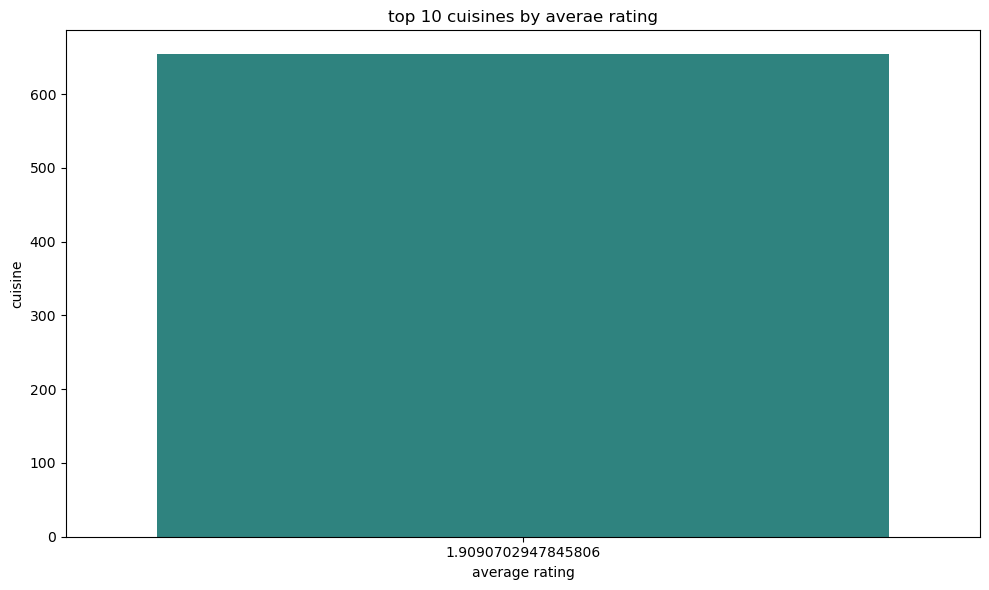

In [5]:
cuisine_count = data_expload['Cuisines'].value_counts()
reliable_cuisine = cuisine_count[cuisine_count > 30].index
high_rate= avg_rate.loc[reliable_cuisine].sort_values(ascending = False)
plt.figure(figsize = (10,6))
sns.barplot(x = high_rate.head(5), y = high_rate.head(5).index,palette = 'viridis')
plt.title('top 10 cuisines by averae rating')
plt.xlabel('average rating')
plt.ylabel('cuisine')
plt.tight_layout()
plt.show()

#data.head(2)

C:\Users\visha\AppData\Local\Temp\ipykernel_3200\1084704696.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = total_votes.head(5), y = total_votes.head(5).index,palette = 'rocket')


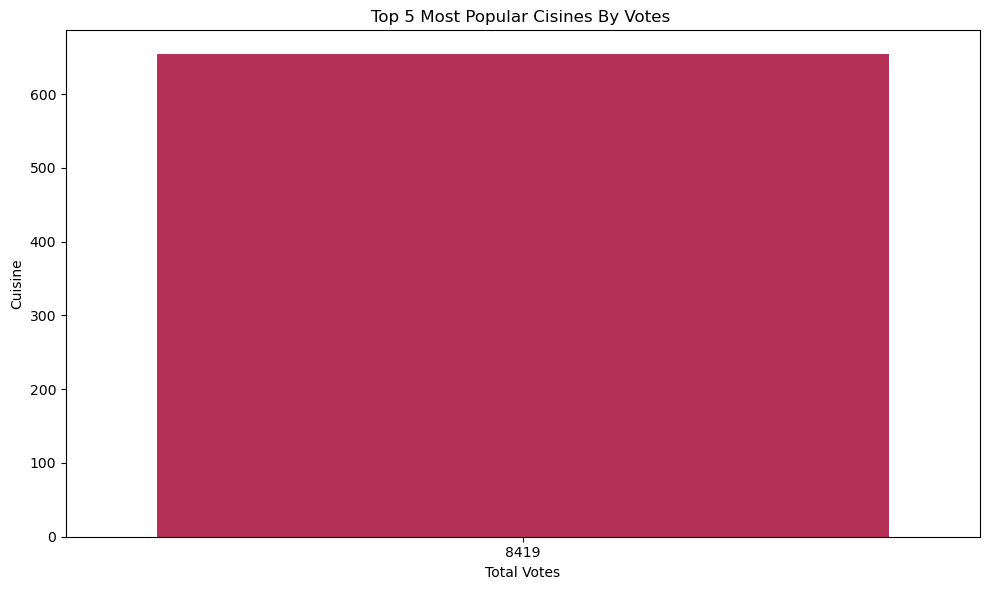

In [6]:
plt.figure(figsize = (10,6))
sns.barplot(x = total_votes.head(5), y = total_votes.head(5).index,palette = 'rocket')
plt.title('Top 5 Most Popular Cisines By Votes ')#top 5 most popular cuisines by votes')
plt.xlabel('Total Votes')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()
#total_votes

In [7]:
data.head(5)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,1897,162,60,4014,120,121,121.027535,14.565443,653.629478,...,0,1,0,0,0,3.0,4.8,0,1,314.0
1,6304287,1611,162,60,2782,422,429,121.014101,14.553708,653.629478,...,0,1,0,0,0,3.0,4.5,0,1,591.0
2,6300002,1461,162,61,2242,233,239,121.056831,14.581404,653.629478,...,0,1,0,0,0,4.0,4.4,1,5,270.0
3,6318506,2365,162,61,4018,560,568,121.056475,14.585318,653.629478,...,0,0,0,0,0,4.0,4.9,0,1,365.0
4,6314302,2756,162,61,4017,560,568,121.057508,14.584450,653.629478,...,0,1,0,0,0,4.0,4.8,0,1,229.0


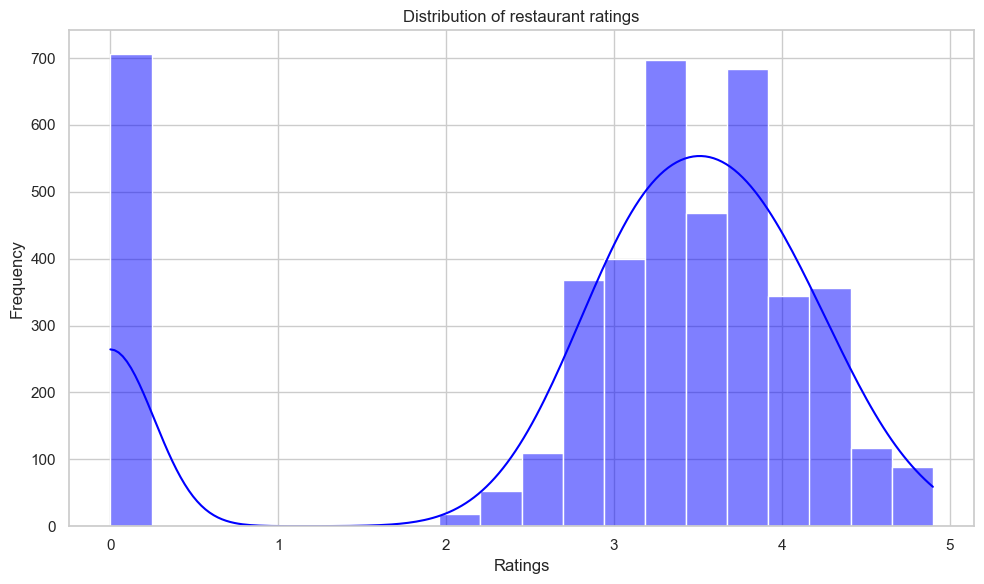

In [8]:
sns.set(style = "whitegrid")
plt.figure(figsize = (10,6))
sns.histplot(data['Aggregate rating'],bins = 20 ,kde = True ,color = 'blue')
plt.title('Distribution of restaurant ratings')#top 5 most popular cuisines by votes')
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\visha\AppData\Local\Temp\ipykernel_3200\3728185075.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Aggregate rating' ,data=data , palette = "coolwarm")#,bins = 20 ,kde = True ,color = 'blue')


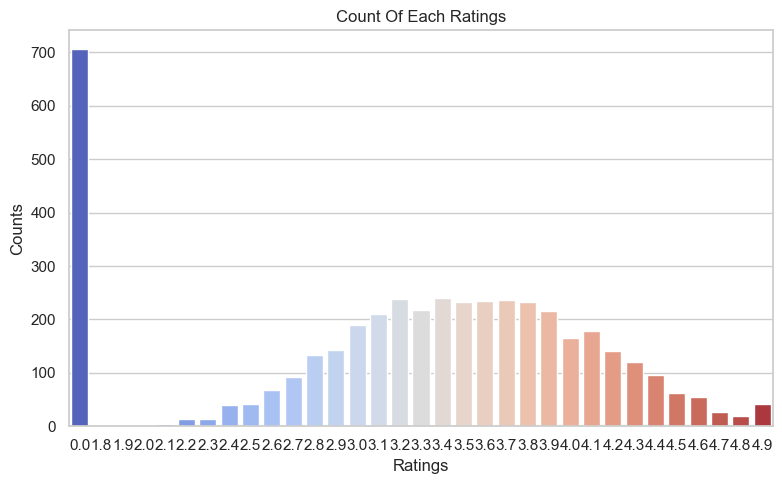

In [9]:
sns.set(style = "whitegrid")
plt.figure(figsize = (8,5))
sns.countplot(x = 'Aggregate rating' ,data=data , palette = "coolwarm")#,bins = 20 ,kde = True ,color = 'blue')
plt.title('Count Of Each Ratings')#top 5 most popular cuisines by votes')
plt.xlabel('Ratings')
plt.ylabel('Counts')
plt.tight_layout()
plt.show()

C:\Users\visha\AppData\Local\Temp\ipykernel_3200\207583418.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = ave_rating_city ,y = ave_rating_city, palette = "magma")#,bins = 20 ,kde = True ,color = 'blue')


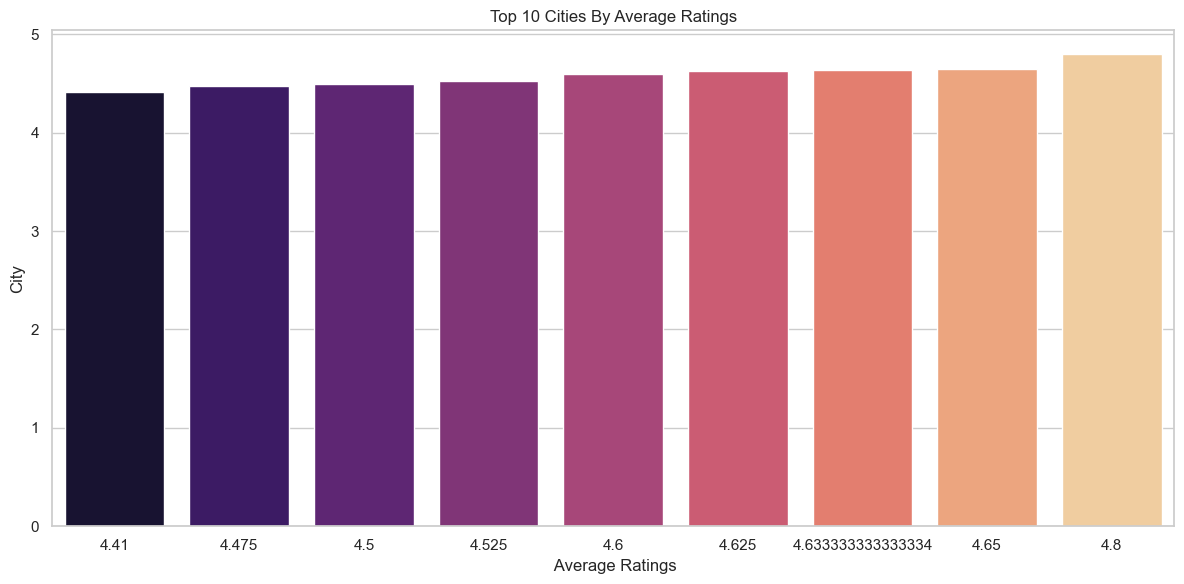

In [10]:
ave_rating_city = data.groupby('City')['Aggregate rating'].mean().sort_values(ascending = False).head(10)
plt.figure(figsize = (12,6))
sns.barplot(x = ave_rating_city ,y = ave_rating_city, palette = "magma")#,bins = 20 ,kde = True ,color = 'blue')
plt.title('Top 10 Cities By Average Ratings')#top 5 most popular cuisines by votes')
plt.xlabel(' Average Ratings')
plt.ylabel('City')
plt.tight_layout()
plt.show()

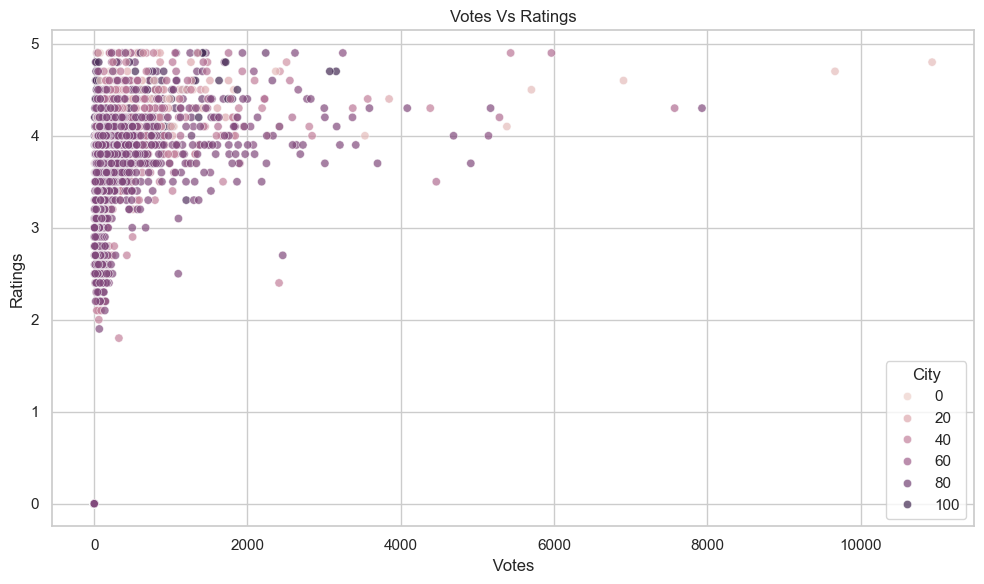

In [11]:
#city = data['City'].shape
#ave_rating_city = data.groupby('City')['Aggregate rating'].mean().sort_values(ascending = False).head(10)
plt.figure(figsize = (10,6))
sns.scatterplot(x = 'Votes' ,y = 'Aggregate rating',data = data ,hue = 'City',alpha = 0.7)#,bins = 20 ,kde = True ,color = 'blue')
plt.title('Votes Vs Ratings')#top 5 most popular cuisines by votes')
plt.xlabel(' Votes ')
plt.ylabel('Ratings')
plt.tight_layout()
plt.show()

C:\Users\visha\AppData\Local\Temp\ipykernel_3200\139238029.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Price range' ,y = 'Aggregate rating',data = data ,palette = 'Set3')#,bins = 20 ,kde = True ,color = 'blue')


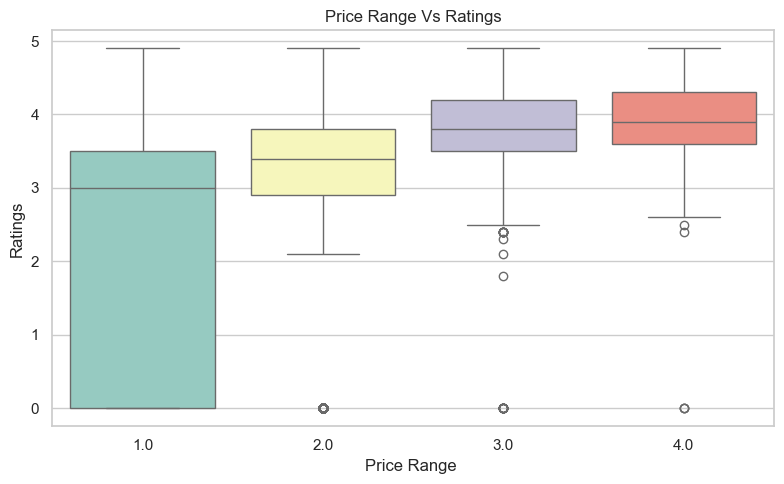

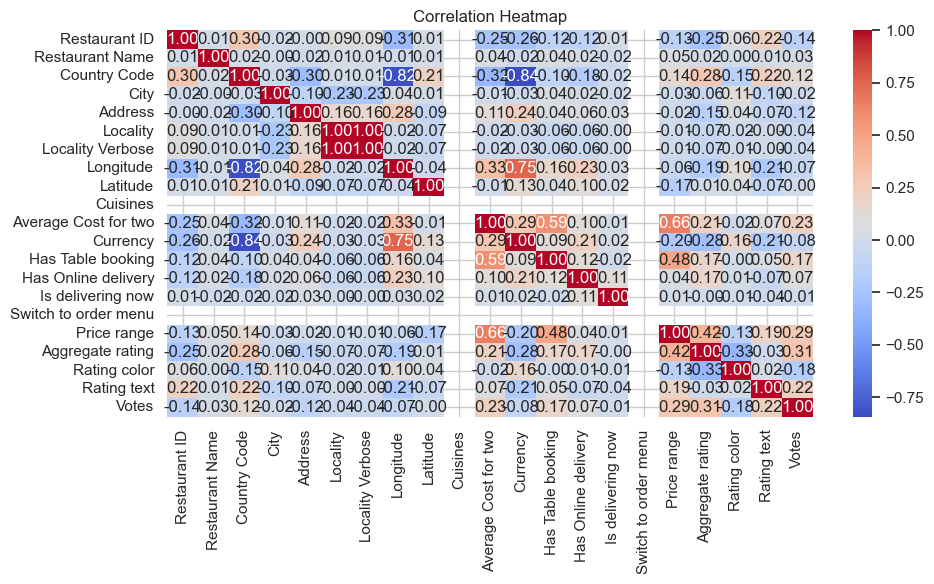

In [13]:
data.head(2)
if data['Price range'].dtype in ['int64', 'float64']:
    plt.figure(figsize = (8,5))
    sns.boxplot(x = 'Price range' ,y = 'Aggregate rating',data = data ,palette = 'Set3')#,bins = 20 ,kde = True ,color = 'blue')
    plt.title('Price Range Vs Ratings')#top 5 most popular cuisines by votes')
    plt.xlabel('Price Range ')
    plt.ylabel('Ratings')
    plt.tight_layout()
    plt.show()

plt.figure(figsize = (10,6))
sns.heatmap(data.corr(numeric_only = True),annot = True ,cmap = 'coolwarm',fmt = '.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
    